# 01 — Leaden 2018 Δ*fur* signature: clean Fur-only DEG reference

**Project**: `caulobacter_fur_lipida_loss` — Phase C, NB01.

## Purpose

Disambiguate Fur-specific vs SspB-specific effects in the colleague's 4584-vs-4580 contrast (which is Δ*fur* Δ*sspB* Δ*rsaA* on a Δ*rsaA* baseline) by referencing it against **Leaden et al. 2018** (PMID 30210482), which compared WT vs Δ*fur* under iron-replete conditions plus WT under iron limitation (`2h DP`).

**Preflight succeeded** — the published supplementary `Table 2.XLSX` is at `~/data/kr-caulobacter-envelope/raw/Table 2.XLSX`; CTS re-analysis from raw SRA is **not** required. This saves ~3-6 h cluster compute.

## Stop condition (per RESEARCH_PLAN v2)

Spearman concordance between Leaden Δ*fur* log2-FC and 4584-vs-4580 log2-FC, over the genes that are differentially expressed in *Leaden* (≈99 genes with logFC reported):

- **≥ 0.30**: pass — Δ*fur* is a major driver of 4584-vs-4580; H2's "critical Fur regulon subset" framing is intact.
- **< 0.30**: fail — Δ*sspB* dominates the 4584-vs-4580 signal; trigger plan reframe at the checkpoint.

A negative or near-zero concordance would suggest the two perturbations push different directions on the same genes — an *anti*-correspondence, also a plan-reframe trigger.

## Outputs

- `data/NB01_leaden_fur_de.csv` — Leaden Δ*fur* DEGs in tidy form
- `data/NB01_leaden_iron_de.csv` — Leaden iron-limitation (2h DP) DEGs
- `data/NB01_fur_only_signature.csv` — H2 candidate Fur-released genes intersected with 4584-vs-4580
- `data/NB01_source_provenance.md` — record that preflight succeeded
- `figures/NB01_fur_signature_scatter.png` — Leaden Δ*fur* logFC vs 4584-vs-4580 logFC scatter
- `figures/NB01_leaden_iron_vs_fur.png` — Leaden's own iron-limitation vs Δ*fur* logFC (internal QC)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import spearmanr, pearsonr
import openpyxl

pd.set_option('display.max_colwidth', 80)
pd.set_option('display.width', 180)
sns.set_context('notebook')
sns.set_style('whitegrid')

PROJ = Path('/home/aparkin/BERIL-research-observatory/projects/caulobacter_fur_lipida_loss')
USERDATA = Path('/home/aparkin/data/kr-caulobacter-envelope')
DATA_OUT = PROJ / 'data'
FIG = PROJ / 'figures'
LEADEN_PATH = USERDATA / 'raw' / 'Table 2.XLSX'

assert LEADEN_PATH.exists(), f'Missing Leaden Table 2 at {LEADEN_PATH}'
print(f'Leaden source: {LEADEN_PATH}')

# colleague's clean tables
diff = pd.read_csv(USERDATA / 'clean' / 'fact_differential.csv')
feat = pd.read_csv(USERDATA / 'clean' / 'dim_feature.csv')
print(f'diff: {diff.shape}, feat: {feat.shape}')


Leaden source: /home/aparkin/data/kr-caulobacter-envelope/raw/Table 2.XLSX
diff: (11871, 8), feat: (4020, 4)


## 1. Parse Leaden Table 2 — multi-sheet → tidy DataFrames

Sheet layout (verified in preflight):

| Sheet | Direction | Source |
|---|---|---|
| `up wt-DP and fur ` | up in BOTH 2h iron-deprivation AND Δ*fur* | both |
| `down wt-DP and fur` | down in both | both |
| `up fur ` | up in Δ*fur* only | Δ*fur* only |
| `down fur` | down in Δ*fur* only | Δ*fur* only |
| `up wt-DP ` | up in 2h DP only | iron-limitation only |
| `down wt-DP` | down in 2h DP only | iron-limitation only |

Each sheet has columns: `#`, `Gene` (CCNA locus), `Fold change (log2) 2h DP`, `Fold change (log2) fur mutant` (some sheets only have one), `Product`, `Category`.

Result: build a long-format DataFrame keyed on (CCNA locus, condition ∈ {fur, iron}) with logFC.


In [2]:
# Load workbook
wb = openpyxl.load_workbook(LEADEN_PATH, data_only=True)
print(f'Sheets: {wb.sheetnames}')

def parse_sheet(ws, sheet_name):
    """Parse one DE sheet to a tidy DataFrame. Returns (df_fur, df_iron) where either may be empty."""
    rows = list(ws.iter_rows(values_only=True))
    if not rows:
        return pd.DataFrame(), pd.DataFrame()
    # Find header row (first row containing 'Gene' in any column)
    header_idx = None
    for i, r in enumerate(rows[:5]):
        if r and any((c or '').strip() == 'Gene' for c in r if isinstance(c, str)):
            header_idx = i
            break
    if header_idx is None:
        return pd.DataFrame(), pd.DataFrame()
    header = [str(c).strip().replace('\n', ' ') if c else '' for c in rows[header_idx]]
    data = [r for r in rows[header_idx+1:] if r and r[1] is not None and isinstance(r[1], str) and r[1].startswith('CCNA_')]
    df = pd.DataFrame(data, columns=header)
    # find logFC columns
    fur_col = next((c for c in df.columns if 'fur' in c.lower() and 'fold' in c.lower()), None)
    iron_col = next((c for c in df.columns if 'dp' in c.lower() and 'fold' in c.lower()), None)
    product_col = next((c for c in df.columns if c.strip() == 'Product'), None)
    cat_col = next((c for c in df.columns if c.strip() == 'Category'), None)
    df_fur = pd.DataFrame()
    df_iron = pd.DataFrame()
    if fur_col:
        df_fur = pd.DataFrame({
            'locustag': df['Gene'].astype(str).str.strip(),
            'log2fc_fur': pd.to_numeric(df[fur_col], errors='coerce'),
            'product': df[product_col].astype(str).str.strip() if product_col else '',
            'category': df[cat_col].astype(str).str.strip() if cat_col else '',
            'leaden_sheet': sheet_name,
        }).dropna(subset=['log2fc_fur'])
    if iron_col:
        df_iron = pd.DataFrame({
            'locustag': df['Gene'].astype(str).str.strip(),
            'log2fc_iron_2hDP': pd.to_numeric(df[iron_col], errors='coerce'),
            'product': df[product_col].astype(str).str.strip() if product_col else '',
            'category': df[cat_col].astype(str).str.strip() if cat_col else '',
            'leaden_sheet': sheet_name,
        }).dropna(subset=['log2fc_iron_2hDP'])
    return df_fur, df_iron

all_fur = []
all_iron = []
for s in wb.sheetnames:
    if s.lower().startswith('summary'):
        continue
    fur, iron = parse_sheet(wb[s], s)
    if not fur.empty: all_fur.append(fur)
    if not iron.empty: all_iron.append(iron)

leaden_fur = pd.concat(all_fur, ignore_index=True).drop_duplicates('locustag')
leaden_iron = pd.concat(all_iron, ignore_index=True).drop_duplicates('locustag')
print(f'Leaden Δfur DEGs (deduplicated): {len(leaden_fur)}')
print(f'Leaden iron-limitation DEGs (deduplicated): {len(leaden_iron)}')

# Direction labels (for clarity)
leaden_fur['direction_fur'] = np.sign(leaden_fur['log2fc_fur']).map({1:'up', -1:'down', 0:'none'})
leaden_iron['direction_iron'] = np.sign(leaden_iron['log2fc_iron_2hDP']).map({1:'up', -1:'down', 0:'none'})

print('\nΔfur direction distribution:')
print(leaden_fur['direction_fur'].value_counts())
print('\nLeaden Δfur sheet contributions:')
print(leaden_fur['leaden_sheet'].value_counts())

display(leaden_fur.head())


Sheets: ['Summary', 'up wt-DP and fur ', 'down wt-DP and fur', 'up fur ', 'down fur', 'up wt-DP ', 'down wt-DP']
Leaden Δfur DEGs (deduplicated): 93
Leaden iron-limitation DEGs (deduplicated): 491

Δfur direction distribution:
direction_fur
down    53
up      40
Name: count, dtype: int64

Leaden Δfur sheet contributions:
leaden_sheet
down wt-DP and fur    38
up wt-DP and fur      23
up fur                17
down fur              15
Name: count, dtype: int64


,locustag,log2fc_fur,product,category,leaden_sheet,direction_fur
0,CCNA_00039,1.738843,hypothetical protein,hypotetical protein,up wt-DP and fur,up
1,CCNA_00263,1.909522,hypothetical protein,hypothetical protein,up wt-DP and fur,up
2,CCNA_03932,2.331872,hypothetical protein,hypothetical protein,up wt-DP and fur,up
3,CCNA_03933,2.474392,hypothetical protein,hypothetical protein,up wt-DP and fur,up
4,CCNA_02278,1.575633,hypothetical protein,hypothetical protein,up wt-DP and fur,up


In [3]:
# Save tidy tables
leaden_fur.to_csv(DATA_OUT / 'NB01_leaden_fur_de.csv', index=False)
leaden_iron.to_csv(DATA_OUT / 'NB01_leaden_iron_de.csv', index=False)
print(f'Saved NB01_leaden_fur_de.csv ({len(leaden_fur)} rows)')
print(f'Saved NB01_leaden_iron_de.csv ({len(leaden_iron)} rows)')


Saved NB01_leaden_fur_de.csv (93 rows)
Saved NB01_leaden_iron_de.csv (491 rows)


## 2. Internal QC — Leaden Δ*fur* vs iron-limitation (2h DP)

Leaden's own data give an upper-bound expectation for what "Fur-like" perturbations look like. Δ*fur* and iron-limitation should be correlated but not identical. Genes that are co-regulated (both up, both down) are the core Fur-iron axis. Genes that respond only to one are condition-specific.


Genes in BOTH Δfur and iron-limitation DEG lists: 62

Leaden internal: Δfur vs iron-limitation logFC
  Spearman ρ = 0.928, p = 2.45e-27
  Pearson  r = 0.938, p = 2.35e-29


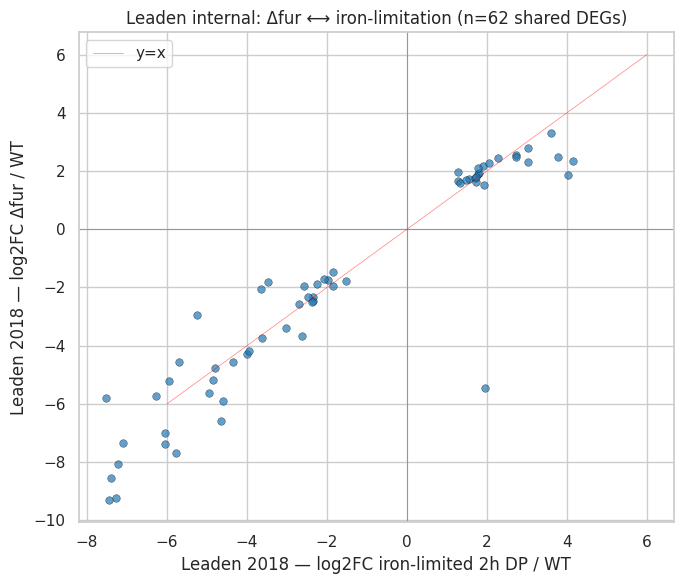

In [4]:
# Merge Leaden's own two signatures on locustag
leaden_merged = leaden_fur[['locustag','log2fc_fur','product','category']].merge(
    leaden_iron[['locustag','log2fc_iron_2hDP']],
    on='locustag', how='outer'
)
both = leaden_merged.dropna(subset=['log2fc_fur','log2fc_iron_2hDP'])
print(f'Genes in BOTH Δfur and iron-limitation DEG lists: {len(both)}')

# Spearman + Pearson over the shared subset
if len(both) >= 5:
    rho_s, p_s = spearmanr(both['log2fc_fur'], both['log2fc_iron_2hDP'])
    rho_p, p_p = pearsonr(both['log2fc_fur'], both['log2fc_iron_2hDP'])
    print(f'\nLeaden internal: Δfur vs iron-limitation logFC')
    print(f'  Spearman ρ = {rho_s:.3f}, p = {p_s:.2e}')
    print(f'  Pearson  r = {rho_p:.3f}, p = {p_p:.2e}')

# Plot
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(both['log2fc_iron_2hDP'], both['log2fc_fur'], alpha=0.7, s=30, edgecolor='k', linewidth=0.3)
ax.axhline(0, color='grey', lw=0.5); ax.axvline(0, color='grey', lw=0.5)
ax.plot([-6,6],[-6,6], color='red', lw=0.5, alpha=0.5, label='y=x')
ax.set_xlabel('Leaden 2018 — log2FC iron-limited 2h DP / WT')
ax.set_ylabel('Leaden 2018 — log2FC Δfur / WT')
ax.set_title(f'Leaden internal: Δfur ⟷ iron-limitation (n={len(both)} shared DEGs)')
ax.legend()
plt.tight_layout()
plt.savefig(FIG / 'NB01_leaden_iron_vs_fur.png', dpi=140, bbox_inches='tight')
plt.show()


## 3. Build the join with the colleague's 4584-vs-4580 contrast

The colleague's `fact_differential.csv` has all loci (significant + non-significant) for the 4584-vs-4580 (Δ*rsaA* Δ*fur* Δ*sspB* vs Δ*rsaA*) contrast. Leaden's Table 2 only reports significant DEGs (no logFC for non-DEGs). So the concordance check is over the genes Leaden flagged as significant, looked up in our data.


In [5]:
# 4584-vs-4580 logFCs by locus
ours = diff[diff['contrast']=='4584_vs_4580'][['locustag','logFC','fdr','pvalue']].rename(
    columns={'logFC':'log2fc_ours','fdr':'fdr_ours','pvalue':'pvalue_ours'})

# Inner join: only genes in Leaden Δfur list with available data in our 4584-vs-4580
joined = leaden_fur[['locustag','log2fc_fur','product','category','leaden_sheet']].merge(
    ours, on='locustag', how='left')

n_total = len(joined)
n_with_ours = joined['log2fc_ours'].notna().sum()
print(f'Leaden Δfur DEGs:           {n_total}')
print(f'Of these, found in our DE:  {n_with_ours} ({n_with_ours/n_total*100:.0f}%)')

# Concordance over genes present in both
both = joined.dropna(subset=['log2fc_ours','log2fc_fur'])
rho_s, p_s = spearmanr(both['log2fc_fur'], both['log2fc_ours'])
rho_p, p_p = pearsonr(both['log2fc_fur'], both['log2fc_ours'])

# Also check sign concordance (binary): same direction?
sign_concord = (np.sign(both['log2fc_fur']) == np.sign(both['log2fc_ours'])).mean()

print(f'\n=== STOP CONDITION CHECK ===')
print(f'Joined pairs: n = {len(both)}')
print(f'Spearman ρ (Leaden Δfur ↔ ours 4584-vs-4580):  {rho_s:.3f},  p = {p_s:.2e}')
print(f'Pearson  r:                                     {rho_p:.3f},  p = {p_p:.2e}')
print(f'Sign concordance (same direction): {sign_concord:.1%}')

VERDICT = 'PASS — Δfur is a major driver' if rho_s >= 0.30 else 'FAIL — trigger plan reframe'
print(f'\nVerdict (threshold ρ ≥ 0.30): {VERDICT}')

joined.to_csv(DATA_OUT / 'NB01_fur_only_signature.csv', index=False)


Leaden Δfur DEGs:           93
Of these, found in our DE:  93 (100%)

=== STOP CONDITION CHECK ===
Joined pairs: n = 93
Spearman ρ (Leaden Δfur ↔ ours 4584-vs-4580):  0.315,  p = 2.08e-03
Pearson  r:                                     0.453,  p = 5.27e-06
Sign concordance (same direction): 71.0%

Verdict (threshold ρ ≥ 0.30): PASS — Δfur is a major driver


## 4. Scatter — Leaden Δ*fur* logFC vs 4584-vs-4580 logFC

Colored by Leaden category (functional class) where annotated.


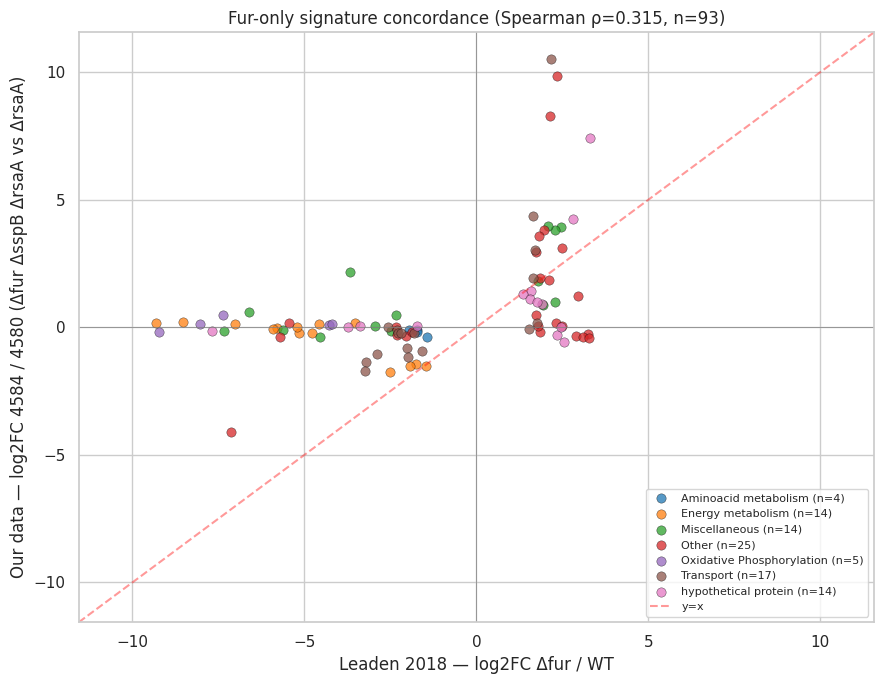

In [6]:
fig, ax = plt.subplots(figsize=(9, 7))
plot_df = both.copy()
# Tidy category — coarse-grain
plot_df['cat_short'] = plot_df['category'].fillna('Other').str.strip().str[:30]
top_cats = plot_df['cat_short'].value_counts().head(6).index.tolist()
plot_df['cat_plot'] = plot_df['cat_short'].where(plot_df['cat_short'].isin(top_cats), 'Other')

palette = sns.color_palette('tab10', n_colors=len(plot_df['cat_plot'].unique()))
for (cat, sub), c in zip(plot_df.groupby('cat_plot'), palette):
    ax.scatter(sub['log2fc_fur'], sub['log2fc_ours'], label=f'{cat} (n={len(sub)})',
               alpha=0.75, s=45, edgecolor='k', linewidth=0.3, color=c)

# y=x line
lim = max(abs(plot_df['log2fc_fur']).max(), abs(plot_df['log2fc_ours']).max()) * 1.1
ax.plot([-lim, lim], [-lim, lim], '--', color='red', alpha=0.4, label='y=x')
ax.axhline(0, color='grey', lw=0.5); ax.axvline(0, color='grey', lw=0.5)
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.set_xlabel('Leaden 2018 — log2FC Δfur / WT')
ax.set_ylabel('Our data — log2FC 4584 / 4580 (Δfur ΔsspB ΔrsaA vs ΔrsaA)')
ax.set_title(f'Fur-only signature concordance (Spearman ρ={rho_s:.3f}, n={len(both)})')
ax.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.savefig(FIG / 'NB01_fur_signature_scatter.png', dpi=140, bbox_inches='tight')
plt.show()


## 5. Genes diagnosed as Fur-only, SspB-influenced, or divergent

Categorize Leaden Δ*fur* DEGs by behavior in our 4584-vs-4580 contrast:
- **Concordant strong**: same direction, |logFC ours| > 1
- **Concordant weak**: same direction, |logFC ours| ≤ 1 (likely Fur effect partially masked by SspB)
- **Discordant**: opposite direction (likely SspB-dominant or context-dependent)
- **Not differential in ours**: |logFC ours| < 0.5 (Fur effect compensated/buffered in our background)


In [7]:
def categorize(row):
    if pd.isna(row['log2fc_ours']):
        return 'missing'
    same_dir = np.sign(row['log2fc_fur']) == np.sign(row['log2fc_ours'])
    abs_ours = abs(row['log2fc_ours'])
    if not same_dir and abs_ours > 0.5:
        return 'discordant'
    if same_dir and abs_ours > 1:
        return 'concordant_strong'
    if same_dir and abs_ours > 0.5:
        return 'concordant_weak'
    return 'buffered'

joined['category_call'] = joined.apply(categorize, axis=1)
cat_counts = joined['category_call'].value_counts()
print('Category breakdown for Leaden Δfur DEGs:')
print(cat_counts)
print()

# Show concordant-strong (the core Fur signature)
print('=== Concordant-strong: clean Fur signature in our data ===')
disp_cols = ['locustag','log2fc_fur','log2fc_ours','fdr_ours','product','category']
strong = joined[joined['category_call']=='concordant_strong'].sort_values('log2fc_fur', ascending=False)
display(strong[disp_cols])

print('\n=== Discordant: opposing Δfur and 4584-vs-4580 (SspB-dominant?) ===')
disc = joined[joined['category_call']=='discordant'].sort_values('log2fc_fur', ascending=False)
display(disc[disp_cols])

print('\n=== Buffered: significant in Leaden Δfur, not in our data ===')
buff = joined[joined['category_call']=='buffered'].sort_values('log2fc_fur', ascending=False)
display(buff[disp_cols].head(20))


Category breakdown for Leaden Δfur DEGs:
category_call
buffered             53
concordant_strong    32
concordant_weak       5
discordant            3
Name: count, dtype: int64

=== Concordant-strong: clean Fur signature in our data ===


,locustag,log2fc_fur,log2fc_ours,fdr_ours,product,category
6,CCNA_03904,3.292590,7.424133,9.818341e-09,hypothetical protein,hypothetical protein
77,CCNA_R0088,2.961138,1.221972,2.028937e-02,minimal medium expressed sRNA,non-coding RNA
5,CCNA_02452,2.797598,4.263908,4.008802e-08,hypothetical protein,hypothetical protein
8,CCNA_03372,2.481713,3.089329,7.714849e-04,bacterioferritin-associated ferredoxin,iron metabolism
12,CCNA_03155,2.450797,3.935256,3.445656e-05,PepSY-associated transmembrane protein,Miscellaneous
75,CCNA_02275,2.335534,9.847587,9.778952e-09,"ABC transporter, periplasmic component",transport
13,CCNA_03156,2.286528,3.798423,9.233978e-05,putative periplasmic protein,Miscellaneous
20,CCNA_02277,2.173145,10.510821,6.676913e-10,TonB-dependent outer membrane channel,Transport
70,CCNA_02274,2.148901,8.265150,1.339354e-09,EF-Hand domain protein,miscellaneous
71,CCNA_00733,2.109850,1.838164,3.136734e-05,GumN superfamily protein,miscellaneous



=== Discordant: opposing Δfur and 4584-vs-4580 (SspB-dominant?) ===


,locustag,log2fc_fur,log2fc_ours,fdr_ours,product,category
7,CCNA_02999,2.539398,-0.566960,0.101232,hypothetical protein,hypothetical protein
47,CCNA_01519,-3.679348,2.185417,0.000003,universal stress protein family,Miscellaneous
43,CCNA_00754,-6.604926,0.602951,0.256430,Nodulin-21 / CCC1-related protein,Miscellaneous



=== Buffered: significant in Leaden Δfur, not in our data ===


,locustag,log2fc_fur,log2fc_ours,fdr_ours,product,category
65,CCNA_01851,3.288361,-0.411724,0.827810,quinol cytochrome oxidase polypeptide II,energy metabolism
62,CCNA_01847,3.242669,-0.248265,0.924899,cytochrome c oxidase assembly protein Surf1,energy metabolism
64,CCNA_01850,3.103049,-0.394538,0.843285,quinol cytochrome oxidase polypeptide I,energy metabolism
63,CCNA_01848,2.894681,-0.344636,0.862939,quinol cytochrome oxidase polypeptide IV,energy metabolism
73,CCNA_02723,2.486727,0.049502,0.923812,PAS domain protein,signal transduction
3,CCNA_03933,2.474392,0.001013,0.999616,hypothetical protein,hypothetical protein
2,CCNA_03932,2.331872,-0.295854,0.946246,hypothetical protein,hypothetical protein
61,CCNA_03770,2.313741,0.150902,0.502711,malate dehydrogenase,Carbon metabolism
22,CCNA_R0117,1.857451,-0.196825,0.467961,small non-coding RNA,non-coding RNA
72,CCNA_02255,1.784785,0.040099,0.889995,lysozyme-family localization factor spmX,miscellaneous


## 6. Provenance and summary


In [8]:
prov = f'''# NB01 source provenance — Leaden 2018 Fur-only signature

Date: {pd.Timestamp.now().isoformat(timespec='seconds')}Z
Source: Leaden et al. 2018, Frontiers in Microbiology (PMID 30210482; PMC6120978)
File: ~/data/kr-caulobacter-envelope/raw/Table 2.XLSX (published supplementary)
Status: PREFLIGHT SUCCESS — CTS re-analysis from raw SRA was not required.
Sheets parsed: {[s for s in wb.sheetnames if not s.lower().startswith("summary")]}
Leaden Δfur DEGs (deduplicated): {len(leaden_fur)}
Leaden iron-limitation (2h DP) DEGs: {len(leaden_iron)}
'''
(DATA_OUT / 'NB01_source_provenance.md').write_text(prov)
print(prov)


# NB01 source provenance — Leaden 2018 Fur-only signature

Date: 2026-06-04T02:22:07Z
Source: Leaden et al. 2018, Frontiers in Microbiology (PMID 30210482; PMC6120978)
File: ~/data/kr-caulobacter-envelope/raw/Table 2.XLSX (published supplementary)
Status: PREFLIGHT SUCCESS — CTS re-analysis from raw SRA was not required.
Sheets parsed: ['up wt-DP and fur ', 'down wt-DP and fur', 'up fur ', 'down fur', 'up wt-DP ', 'down wt-DP']
Leaden Δfur DEGs (deduplicated): 93
Leaden iron-limitation (2h DP) DEGs: 491



In [9]:
print('=== NB01 SUMMARY ===\n')
print(f'Leaden Δfur DEGs:                {len(leaden_fur)}')
print(f'Leaden iron-limitation DEGs:     {len(leaden_iron)}')
print(f'Shared (both Δfur AND iron):     {len(leaden_merged.dropna(subset=["log2fc_fur","log2fc_iron_2hDP"]))}')
print()
print(f'Joined with our 4584-vs-4580:    {len(both)} of {n_total} Leaden Δfur DEGs')
print(f'Spearman concordance:            ρ = {rho_s:.3f}, p = {p_s:.2e}')
print(f'Sign concordance:                {sign_concord:.1%}')
print(f'Stop condition (ρ ≥ 0.30):       {VERDICT}')
print()
print('Category breakdown:')
print(cat_counts.to_string())
print()
print('NEXT — feed concordant_strong (core Fur signature) to NB02 for phenotype ranking via RB-TnSeq.')


=== NB01 SUMMARY ===

Leaden Δfur DEGs:                93
Leaden iron-limitation DEGs:     491
Shared (both Δfur AND iron):     62

Joined with our 4584-vs-4580:    93 of 93 Leaden Δfur DEGs
Spearman concordance:            ρ = 0.315, p = 2.08e-03
Sign concordance:                71.0%
Stop condition (ρ ≥ 0.30):       PASS — Δfur is a major driver

Category breakdown:
category_call
buffered             53
concordant_strong    32
concordant_weak       5
discordant            3

NEXT — feed concordant_strong (core Fur signature) to NB02 for phenotype ranking via RB-TnSeq.
